In [1]:
from pathlib import Path
OUTPUT_DIR = Path('/Users/fteodoro/Dropbox/Doutorado/Tese/figuras')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

DATA_DIR = Path('/Users/fteodoro/Dropbox/Doutorado/Fontes/LearnableWaveletLayer/data')

In [3]:
def compute_log_features(df):
    """Compute 5 log-ratio features from OHLCV."""
    feat = pd.DataFrame(index=df.index)
    feat['log_ret']    = np.log(df['Close'] / df['Close'].shift(1))
    feat['log_hl']     = np.log(df['High'] / df['Low'])
    feat['log_co']     = np.log(df['Close'] / df['Open'])
    feat['log_ho']     = np.log(df['High'] / df['Open'])
    feat['log_lo']     = np.log(df['Low'] / df['Open'])
    return feat.dropna()


def triple_barrier_labels(close: pd.Series,
                          sigma: pd.Series,
                          k_u: float = 2.0,
                          k_d: float = 2.0,
                          T_max: int = 10) -> pd.Series:
    """
    Triple Barrier Method labels.
    Returns +1 (buy), -1 (sell), 0 (neutral/timeout).
    """
    labels = pd.Series(0, index=close.index, dtype=int)
    log_close = np.log(close)

    for i in range(len(close) - T_max):
        t0 = close.index[i]
        p0 = log_close.iloc[i]
        sig = sigma.iloc[i]

        upper = p0 + k_u * sig
        lower = p0 - k_d * sig

        window = log_close.iloc[i + 1: i + 1 + T_max]
        label = 0
        for p in window:
            if p >= upper:
                label = 1
                break
            elif p <= lower:
                label = -1
                break
        labels.iloc[i] = label

    return labels


csv_files = sorted(DATA_DIR.glob('*.csv'))
print(f'Found {len(csv_files)} CSV files.')

Found 25 CSV files.


In [4]:
results = []

for csv_path in csv_files:
    ticker = csv_path.stem  # e.g. PETR4.SA
    short  = ticker.replace('.SA', '')

    try:
        df = pd.read_csv(csv_path, index_col='Date', parse_dates=True)
        df = df.sort_index()
        df = df.dropna(subset=['Close', 'High', 'Low', 'Open', 'Volume'])

        if len(df) < 50:
            print(f'  Skipping {short}: too few rows ({len(df)})')
            continue

        # EWM volatility
        log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        sigma   = log_ret.ewm(span=100).std()
        sigma   = sigma.reindex(df.index).ffill().bfill()

        labels = triple_barrier_labels(df['Close'], sigma, k_u=2.0, k_d=2.0, T_max=10)

        # Drop neutral
        labels = labels[labels != 0]

        n_buy  = (labels ==  1).sum()
        n_sell = (labels == -1).sum()
        total  = n_buy + n_sell

        results.append({'ticker': short, 'buy': n_buy, 'sell': n_sell, 'total': total})
        print(f'  {short}: buy={n_buy}, sell={n_sell}')

    except Exception as e:
        print(f'  Error {short}: {e}')

df_res = pd.DataFrame(results).sort_values('total', ascending=False).reset_index(drop=True)
print(df_res)

  ABEV3: buy=2036, sell=1673
  B3SA3: buy=1673, sell=1553
  BBAS3: buy=2116, sell=1843
  BBDC4: buy=1623, sell=1491
  BRKM5: buy=1837, sell=1971
  COGN3: buy=1296, sell=1236
  CSNA3: buy=1922, sell=2004
  CYRE3: buy=2057, sell=1794
  EZTC3: buy=1918, sell=1593
  GGBR4: buy=1978, sell=1815
  HYPE3: buy=1697, sell=1563
  ITUB4: buy=2143, sell=1767
  LREN3: buy=1980, sell=1614
  MGLU3: buy=1362, sell=1407
  MRVE3: buy=1691, sell=1663
  MULT3: buy=1737, sell=1555
  PETR4: buy=2062, sell=1765
  RADL3: buy=2006, sell=1575
  RENT3: buy=2169, sell=1677
  SUZB3: buy=1455, sell=749
  UGPA3: buy=1944, sell=1151
  USIM5: buy=1981, sell=2004
  VALE3: buy=2120, sell=1852
  VIVT3: buy=1964, sell=1623
  WEGE3: buy=2040, sell=1555
   ticker   buy  sell  total
0   USIM5  1981  2004   3985
1   VALE3  2120  1852   3972
2   BBAS3  2116  1843   3959
3   CSNA3  1922  2004   3926
4   ITUB4  2143  1767   3910
5   CYRE3  2057  1794   3851
6   RENT3  2169  1677   3846
7   PETR4  2062  1765   3827
8   BRKM5  1837

Saved: /Users/fteodoro/Dropbox/Doutorado/Tese/figuras/fig_label_distribution.pdf


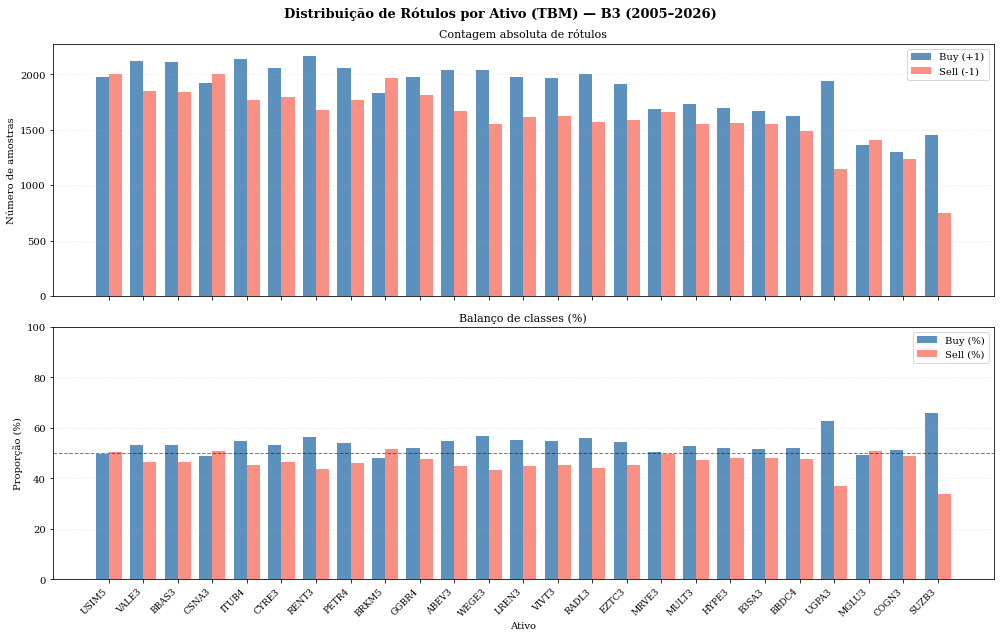

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Distribuição de Rótulos por Ativo (TBM) — B3 (2005–2026)',
             fontsize=13, fontweight='bold')

tickers = df_res['ticker'].tolist()
x = np.arange(len(tickers))
w = 0.38

# Panel 1 – Absolute counts
bars_buy  = ax1.bar(x - w/2, df_res['buy'],  width=w, color='steelblue', label='Buy (+1)',  alpha=0.88)
bars_sell = ax1.bar(x + w/2, df_res['sell'], width=w, color='salmon',    label='Sell (-1)', alpha=0.88)
ax1.set_ylabel('Número de amostras')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.35, ls=':')
ax1.set_title('Contagem absoluta de rótulos', fontsize=11)

# Panel 2 – Class balance %
buy_pct  = df_res['buy']  / df_res['total'] * 100
sell_pct = df_res['sell'] / df_res['total'] * 100

ax2.bar(x - w/2, buy_pct,  width=w, color='steelblue', label='Buy (%)',  alpha=0.88)
ax2.bar(x + w/2, sell_pct, width=w, color='salmon',    label='Sell (%)', alpha=0.88)
ax2.axhline(50, color='black', ls='--', lw=1, alpha=0.5)
ax2.set_ylim(0, 100)
ax2.set_ylabel('Proporção (%)')
ax2.set_xlabel('Ativo')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.35, ls=':')
ax2.set_title('Balanço de classes (%)', fontsize=11)

ax2.set_xticks(x)
ax2.set_xticklabels(tickers, rotation=45, ha='right', fontsize=9)

fig.tight_layout()
out_path = OUTPUT_DIR / 'fig_label_distribution.pdf'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()